# Анализ признаков premium и premium_wo_term

Цель: оценить качество и полезность признаков `premium` и `premium_wo_term` на уровне полиса (contract-level) для frequency-severity модели и их влияние на loss_ratio.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pointbiserialr

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")

In [11]:
DATA_PATH = "dataset/train.csv"
COL_PREMIUM = "premium"
COL_PREMIUM_WO_TERM = "premium_wo_term"

TARGETS = ["is_claim", "claim_amount"]

df = pd.read_csv(DATA_PATH)
df[["contract_number", COL_PREMIUM, COL_PREMIUM_WO_TERM] + TARGETS].head()

/tmp/ipykernel_1656356/1122739535.py:7: DtypeWarning: Columns (0: bonus_malus, 1: car_year) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH)


,contract_number,premium,premium_wo_term,is_claim,claim_amount
0,30f1c038516aaa697b828a90080f6f8e6d5d262b1dd48b...,11691.0,11691.0,0,NaN
1,6eb065f0890396984fd1c6e7b71c3d1643f345906a8c59...,14121.0,14121.0,0,NaN
2,369c23be5e6c413661e872e20bc682df54ccc7f2eb0193...,7371.0,4483.0,0,NaN
3,3b3ed5c1bbde3d6d964449851f08f46b201a2391e25ce2...,20005.0,8550.0,0,NaN
4,66f874dd0dcd62c3503e04bd55972895ecdd83aa511390...,13718.0,2518.0,0,NaN


In [12]:
# Агрегируем до уровня полиса, чтобы избежать искусственного увеличения выборки

def _mode_or_multi(series: pd.Series):
    values = series.dropna()
    if values.empty:
        return np.nan
    uniq = values.unique()
    if len(uniq) == 1:
        return uniq[0]
    return "MULTI"

# Проверим, что premium и premium_wo_term одинаковы внутри договора
premium_multi = df.groupby("contract_number")[COL_PREMIUM].nunique().gt(1).mean()
premium_wo_term_multi = df.groupby("contract_number")[COL_PREMIUM_WO_TERM].nunique().gt(1).mean()
print(f"Доля полисов с разными premium внутри договора: {premium_multi:.6f}")
print(f"Доля полисов с разными premium_wo_term внутри договора: {premium_wo_term_multi:.6f}")

agg_map = {
    COL_PREMIUM: "first",
    COL_PREMIUM_WO_TERM: "first",
    "claim_amount": "first",
    "claim_cnt": "first",
    "is_claim": "first",
}

df_contract = (
    df.groupby("contract_number", as_index=False)
      .agg(agg_map)
)

df_contract.head()

Доля полисов с разными premium внутри договора: 0.000000
Доля полисов с разными premium_wo_term внутри договора: 0.000000


,contract_number,premium,premium_wo_term,claim_amount,claim_cnt,is_claim
0,000153ebe13e6fff0f59b2977d403c82ca2a97f3133d96...,16195.0,16195.0,NaN,NaN,0
1,0001a1cb0431d08f3ccb0a5ec65349678dad2266de183d...,14289.0,14289.0,NaN,NaN,0
2,0001e313d188345c3faa257552bd4287469bf7268229e0...,7249.0,7249.0,NaN,NaN,0
3,0001e54c51ced85c85e97021b85639040db9301adc151e...,6483.0,6483.0,NaN,NaN,0
4,0001ecb71a613337bd5264c47e8383d56b5428994b94fd...,5949.0,291.0,NaN,NaN,0


In [13]:
# Построение loss_ratio

def safe_loss_ratio(claim_sum: float, premium_sum: float) -> float:
    if premium_sum and premium_sum > 0:
        return claim_sum / premium_sum
    return np.nan

df_contract["loss_ratio"] = df_contract.apply(
    lambda row: safe_loss_ratio(row["claim_amount"], row[COL_PREMIUM_WO_TERM]), axis=1
)

overall_lr = safe_loss_ratio(df_contract["claim_amount"].sum(), df_contract[COL_PREMIUM_WO_TERM].sum())
print(f"Loss ratio overall: {overall_lr:.6f}")

df_contract[[COL_PREMIUM, COL_PREMIUM_WO_TERM, "claim_amount", "loss_ratio"]].head()

Loss ratio overall: 1.233424


,premium,premium_wo_term,claim_amount,loss_ratio
0,16195.0,16195.0,NaN,NaN
1,14289.0,14289.0,NaN,NaN
2,7249.0,7249.0,NaN,NaN
3,6483.0,6483.0,NaN,NaN
4,5949.0,291.0,NaN,NaN


=== Summary premium ===


,premium
count,180635.000000
mean,13185.898923
std,7416.335868
min,147.000000
1%,3049.000000
5%,4802.000000
10%,5737.000000
25%,8210.000000
50%,11431.000000
75%,16204.000000


=== Summary premium_wo_term ===


,premium_wo_term
count,180635.000000
mean,10645.020566
std,7952.612079
min,0.000000
1%,0.000000
5%,333.000000
10%,1088.400000
25%,5171.000000
50%,9526.000000
75%,14549.000000


=== Summary premium_wo_term / premium ===


,premium_wo_term_ratio
count,180635.000000
mean,0.802718
std,0.350312
min,0.000000
1%,0.000000
5%,0.035656
10%,0.114125
25%,0.731503
50%,1.000000
75%,1.000000


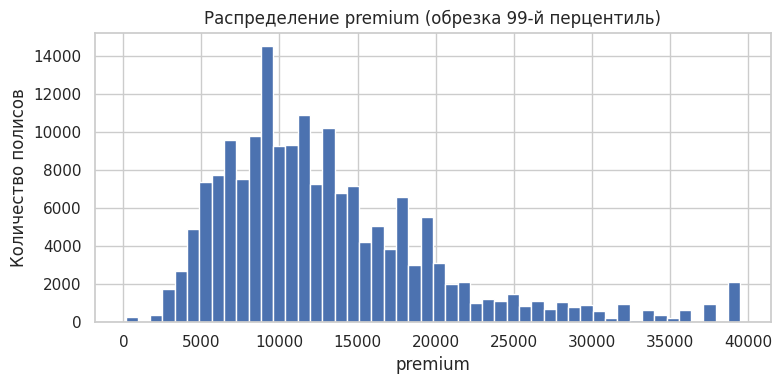

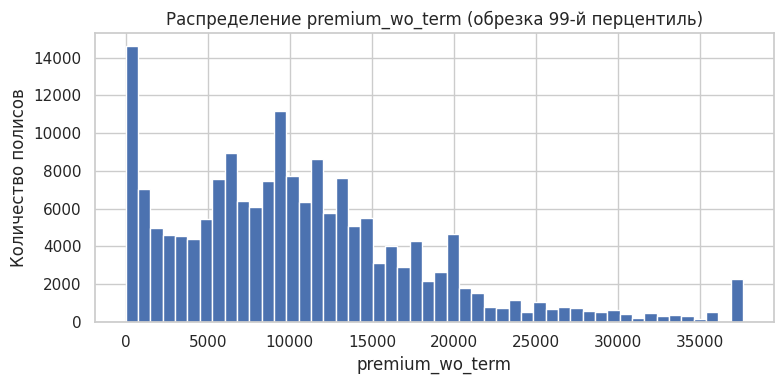

In [14]:
# Distribution analysis: пропуски, перцентили, кардинальность

def describe_numeric(series: pd.Series, name: str) -> pd.DataFrame:
    series_clean = series.dropna()
    percentiles = [0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
    desc = series_clean.describe(percentiles=percentiles).to_frame(name)
    desc.loc["missing_rate", name] = series.isna().mean()
    desc.loc["cardinality", name] = series_clean.nunique()
    return desc

stats_premium = describe_numeric(df_contract[COL_PREMIUM], COL_PREMIUM)
stats_premium_wo = describe_numeric(df_contract[COL_PREMIUM_WO_TERM], COL_PREMIUM_WO_TERM)

print("=== Summary premium ===")
display(stats_premium)
print("=== Summary premium_wo_term ===")
display(stats_premium_wo)

ratio = df_contract[COL_PREMIUM_WO_TERM] / df_contract[COL_PREMIUM]
print("=== Summary premium_wo_term / premium ===")
display(describe_numeric(ratio.replace([np.inf, -np.inf], np.nan), "premium_wo_term_ratio"))

plt.figure(figsize=(8, 4))
df_contract[COL_PREMIUM].clip(upper=df_contract[COL_PREMIUM].quantile(0.99)).hist(bins=50)
plt.title("Распределение premium (обрезка 99-й перцентиль)")
plt.xlabel("premium")
plt.ylabel("Количество полисов")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
df_contract[COL_PREMIUM_WO_TERM].clip(upper=df_contract[COL_PREMIUM_WO_TERM].quantile(0.99)).hist(bins=50)
plt.title("Распределение premium_wo_term (обрезка 99-й перцентиль)")
plt.xlabel("premium_wo_term")
plt.ylabel("Количество полисов")
plt.tight_layout()
plt.show()

In [15]:
# Корреляции с таргетами (contract-level)

def correlation_table(data: pd.DataFrame, feature: str) -> pd.DataFrame:
    rows = []
    for target in ["is_claim", "claim_amount", "loss_ratio"]:
        pearson = data[feature].corr(data[target], method="pearson")
        spearman = data[feature].corr(data[target], method="spearman")
        point_biserial = np.nan
        if target == "is_claim":
            valid = data[[feature, target]].dropna()
            if valid[target].nunique() > 1:
                point_biserial = pointbiserialr(valid[feature], valid[target]).statistic
        rows.append({
            "feature": feature,
            "target": target,
            "pearson": pearson,
            "spearman": spearman,
            "point_biserial": point_biserial,
        })
    return pd.DataFrame(rows)

corr_premium = correlation_table(df_contract, COL_PREMIUM)
corr_premium_wo = correlation_table(df_contract, COL_PREMIUM_WO_TERM)

corr_table = pd.concat([corr_premium, corr_premium_wo], ignore_index=True)
print("=== Correlations ===")
display(corr_table)

=== Correlations ===


,feature,target,pearson,spearman,point_biserial
0,premium,is_claim,0.063194,0.063685,0.063194
1,premium,claim_amount,-0.031735,-0.045874,NaN
2,premium,loss_ratio,-0.089617,-0.419907,NaN
3,premium_wo_term,is_claim,0.087215,0.087184,0.087215
4,premium_wo_term,claim_amount,-0.023697,-0.028144,NaN
5,premium_wo_term,loss_ratio,-0.149931,-0.479059,NaN


In [16]:
# WoE/IV для непрерывных признаков через биннинг

def bin_continuous(series: pd.Series, bins: int = 10) -> pd.Series:
    clean = series.replace([np.inf, -np.inf], np.nan)
    return pd.qcut(clean, q=bins, duplicates="drop")

def woe_iv_binned(data: pd.DataFrame, feature: str, target: str, bins: int = 10) -> tuple[pd.DataFrame, float]:
    df_tmp = data[[feature, target]].copy()
    df_tmp["bin"] = bin_continuous(df_tmp[feature], bins=bins).astype(str).fillna("MISSING")

    total_good = (df_tmp[target] == 0).sum()
    total_bad = (df_tmp[target] == 1).sum()

    agg = (
        df_tmp.groupby("bin")[target]
        .agg(["count", "sum"])
        .rename(columns={"sum": "bad"})
    )
    agg["good"] = agg["count"] - agg["bad"]

    # Сглаживание, чтобы избежать деления на ноль
    agg["bad_rate"] = (agg["bad"] + 0.5) / (total_bad + 1.0)
    agg["good_rate"] = (agg["good"] + 0.5) / (total_good + 1.0)
    agg["woe"] = np.log(agg["good_rate"] / agg["bad_rate"])
    agg["iv"] = (agg["good_rate"] - agg["bad_rate"]) * agg["woe"]

    iv_total = agg["iv"].sum()
    return agg.sort_values("iv", ascending=False), iv_total

woe_premium, iv_premium = woe_iv_binned(df_contract, COL_PREMIUM, "is_claim", bins=10)
woe_premium_wo, iv_premium_wo = woe_iv_binned(df_contract, COL_PREMIUM_WO_TERM, "is_claim", bins=10)

print(f"IV premium (is_claim): {iv_premium:.6f}")
display(woe_premium.head(10))
print(f"IV premium_wo_term (is_claim): {iv_premium_wo:.6f}")
display(woe_premium_wo.head(10))

IV premium (is_claim): 0.227048


,count,bad,good,bad_rate,good_rate,woe,iv
bin,,,,,,,
"(146.999, 5737.0]",18072,128,17944,0.035934,0.101346,1.036861,0.067824
"(21782.0, 116896.0]",17930,663,17267,0.185543,0.097523,-0.643197,0.056614
"(5737.0, 7350.0]",18061,164,17897,0.046001,0.101081,0.787256,0.043362
"(18001.0, 21782.0]",17357,512,16845,0.143317,0.095140,-0.409711,0.019739
"(14865.0, 18001.0]",18857,521,18336,0.145833,0.103560,-0.342310,0.014470
"(7350.0, 8984.0]",18302,241,18061,0.067534,0.102007,0.412419,0.014218
"(8984.0, 10077.8]",17819,260,17559,0.072847,0.099172,0.308498,0.008121
"(13245.0, 14865.0]",17764,402,17362,0.112556,0.098059,-0.137877,0.001999
"(10077.8, 11431.0]",18116,331,17785,0.092701,0.100448,0.080262,0.000622


IV premium_wo_term (is_claim): 0.531507


,count,bad,good,bad_rate,good_rate,woe,iv
bin,,,,,,,
"(-0.001, 1088.4]",18064,32,18032,0.009088,0.101843,2.416441,0.224137
"(1088.4, 3824.0]",18064,87,17977,0.024469,0.101533,1.422988,0.109661
"(19910.0, 116896.0]",17741,771,16970,0.215744,0.095845,-0.811354,0.097280
"(16055.0, 19910.0]",18286,626,17660,0.175196,0.099742,-0.563312,0.042504
"(3824.0, 6081.0]",18168,201,17967,0.056348,0.101476,0.588281,0.026548
"(13337.0, 16055.0]",18146,506,17640,0.141639,0.099630,-0.351821,0.014780
"(6081.0, 8021.0]",17974,248,17726,0.069491,0.100115,0.365124,0.011182
"(8021.0, 9526.0]",19152,325,18827,0.091023,0.106333,0.155462,0.002380
"(11297.0, 13337.0]",17685,401,17284,0.112276,0.097619,-0.139892,0.002050


In [17]:
# Segment-level profitability analysis

def segment_profitability(data: pd.DataFrame, feature: str, bins: int = 10) -> pd.DataFrame:
    cols = [feature, "loss_ratio", "is_claim", "claim_amount", COL_PREMIUM_WO_TERM]
    cols = list(dict.fromkeys(cols))
    df_tmp = data[cols].copy()
    df_tmp["bin"] = bin_continuous(df_tmp[feature], bins=bins)

    stats = (
        df_tmp.groupby("bin", observed=True)
        .agg(
            policies=("loss_ratio", "count"),
            loss_ratio_mean=("loss_ratio", "mean"),
            loss_ratio_median=("loss_ratio", "median"),
            high_lr_share=("loss_ratio", lambda x: (x > 1).mean()),
            extreme_lr_share=("loss_ratio", lambda x: (x > 2).mean()),
            claim_rate=("is_claim", "mean"),
            claim_amount_mean=("claim_amount", "mean"),
            premium_wo_term_sum=(COL_PREMIUM_WO_TERM, "sum"),
        )
        .reset_index()
    )

    stats["premium_wo_term_share"] = stats["premium_wo_term_sum"] / stats["premium_wo_term_sum"].sum()
    return stats.sort_values("bin")

seg_premium = segment_profitability(df_contract, COL_PREMIUM, bins=10)
seg_premium_wo = segment_profitability(df_contract, COL_PREMIUM_WO_TERM, bins=10)

print("=== Segment premium ===")
display(seg_premium)
print("=== Segment premium_wo_term ===")
display(seg_premium_wo)

# Проверка монотонности по mean loss_ratio
seg_premium["bin_order"] = np.arange(len(seg_premium))
seg_premium_wo["bin_order"] = np.arange(len(seg_premium_wo))

mono_premium = seg_premium["bin_order"].corr(seg_premium["loss_ratio_mean"], method="spearman")
mono_premium_wo = seg_premium_wo["bin_order"].corr(seg_premium_wo["loss_ratio_mean"], method="spearman")

print(f"Spearman монотонность (premium): {mono_premium:.6f}")
print(f"Spearman монотонность (premium_wo_term): {mono_premium_wo:.6f}")

=== Segment premium ===


,bin,policies,loss_ratio_mean,loss_ratio_median,high_lr_share,extreme_lr_share,claim_rate,claim_amount_mean,premium_wo_term_sum,premium_wo_term_share
0,"(146.999, 5737.0]",128,203.635911,89.686626,0.007083,0.007083,0.007083,750630.472656,61241561.0,0.031849
1,"(5737.0, 7350.0]",164,186.136409,76.019985,0.009080,0.009080,0.009080,772082.826220,93075597.0,0.048405
2,"(7350.0, 8984.0]",241,128.790772,54.014346,0.013168,0.013113,0.013168,733907.904564,119409666.0,0.062100
3,"(8984.0, 10077.8]",260,77.048722,46.499968,0.014591,0.014591,0.014591,680126.019231,137048055.0,0.071273
4,"(10077.8, 11431.0]",331,85.705814,40.451664,0.018271,0.018271,0.018271,717907.845921,161190408.0,0.083828
5,"(11431.0, 13245.0]",353,68.238524,30.703390,0.019230,0.019230,0.019230,627136.966006,184193812.0,0.095791
6,"(13245.0, 14865.0]",402,107.756366,26.657810,0.022630,0.022630,0.022630,604480.815920,202923072.0,0.105532
7,"(14865.0, 18001.0]",521,51.362229,23.960525,0.027629,0.027629,0.027629,642190.157390,253399093.0,0.131782
8,"(18001.0, 21782.0]",512,42.334599,21.302008,0.029498,0.029268,0.029498,714323.119297,279134924.0,0.145166
9,"(21782.0, 116896.0]",661,26.040921,12.700172,0.036754,0.035137,0.036977,592725.419306,431247102.0,0.224273


=== Segment premium_wo_term ===


,bin,policies,loss_ratio_mean,loss_ratio_median,high_lr_share,extreme_lr_share,claim_rate,claim_amount_mean,premium_wo_term_sum,premium_wo_term_share
0,"(-0.001, 1088.4]",30,1779.138679,593.119431,0.001661,0.001661,0.001771,433134.531250,7199501.0,0.003744
1,"(1088.4, 3824.0]",87,324.605587,167.914428,0.004816,0.004816,0.004816,762225.758621,42621222.0,0.022165
2,"(3824.0, 6081.0]",201,129.593976,78.875486,0.011063,0.011063,0.011063,663349.079602,92346392.0,0.048025
3,"(6081.0, 8021.0]",248,95.997075,54.319505,0.013798,0.013742,0.013798,670427.447581,125952277.0,0.065502
4,"(8021.0, 9526.0]",325,82.009943,46.616695,0.016970,0.016970,0.016970,730048.876923,171143149.0,0.089004
5,"(9526.0, 11297.0]",378,67.774819,39.976844,0.021780,0.021780,0.021780,707022.111111,181590733.0,0.094438
6,"(11297.0, 13337.0]",401,54.358873,29.200417,0.022675,0.022561,0.022675,664558.316708,217035156.0,0.112871
7,"(13337.0, 16055.0]",506,45.203565,25.350679,0.027885,0.027885,0.027885,659370.790514,263515750.0,0.137043
8,"(16055.0, 19910.0]",626,35.337732,20.427021,0.034234,0.034124,0.034234,637874.849042,330873829.0,0.172074
9,"(19910.0, 116896.0]",771,24.060990,13.234182,0.043346,0.041711,0.043459,632910.413204,490585281.0,0.255133


Spearman монотонность (premium): -0.915152
Spearman монотонность (premium_wo_term): -1.000000


In [18]:
# Leakage-check: premium_wo_term участвует в определении loss_ratio

print("Проверка leakage:")
print("- premium_wo_term является знаменателем в loss_ratio -> высокий риск leakage для прогнозирования loss_ratio.")
print("- premium как исходная цена может быть допустима для frequency/claim_amount, но связь с loss_ratio требует осторожности.")

corr_lr_premium = df_contract[COL_PREMIUM].corr(df_contract["loss_ratio"], method="spearman")
corr_lr_premium_wo = df_contract[COL_PREMIUM_WO_TERM].corr(df_contract["loss_ratio"], method="spearman")

print(f"Spearman premium vs loss_ratio: {corr_lr_premium:.6f}")
print(f"Spearman premium_wo_term vs loss_ratio: {corr_lr_premium_wo:.6f}")

Проверка leakage:
- premium_wo_term является знаменателем в loss_ratio -> высокий риск leakage для прогнозирования loss_ratio.
- premium как исходная цена может быть допустима для frequency/claim_amount, но связь с loss_ratio требует осторожности.
Spearman premium vs loss_ratio: -0.419907
Spearman premium_wo_term vs loss_ratio: -0.479059


In [20]:
# Сводный вывод для копирования в чат

def _head_df(df, n=5):
    return df.head(n).to_string()

print("CELL 3: head df")
print(_head_df(df[["contract_number", COL_PREMIUM, COL_PREMIUM_WO_TERM, "is_claim", "claim_amount"]]))
print()

print("CELL 4: multi rates + head df_contract")
print(f"premium_multi: {premium_multi:.6f}")
print(f"premium_wo_term_multi: {premium_wo_term_multi:.6f}")
print(_head_df(df_contract[["contract_number", COL_PREMIUM, COL_PREMIUM_WO_TERM, "is_claim", "claim_amount", "loss_ratio"]]))
print()

print("CELL 5: overall loss_ratio")
print(f"overall_lr: {overall_lr:.6f}")
print()

print("CELL 6: summaries")
print("=== Summary premium ===")
print(stats_premium.to_string())
print("=== Summary premium_wo_term ===")
print(stats_premium_wo.to_string())
print("=== Summary premium_wo_term / premium ===")
print(describe_numeric(ratio.replace([np.inf, -np.inf], np.nan), "premium_wo_term_ratio").to_string())
print()

print("CELL 7: correlations")
print(corr_table.to_string(index=False))
print()

print("CELL 8: IV")
print(f"IV premium (is_claim): {iv_premium:.6f}")
print(f"IV premium_wo_term (is_claim): {iv_premium_wo:.6f}")
print()

print("CELL 9: segments + monotonicity")
print("=== Segment premium ===")
print(seg_premium.to_string(index=False))
print("=== Segment premium_wo_term ===")
print(seg_premium_wo.to_string(index=False))
print(f"Spearman monotonicity premium: {mono_premium:.6f}")
print(f"Spearman monotonicity premium_wo_term: {mono_premium_wo:.6f}")
print()

print("CELL 10: leakage-check")
print("Проверка leakage:")
print("- premium_wo_term является знаменателем в loss_ratio -> высокий риск leakage для прогнозирования loss_ratio.")
print("- premium как исходная цена может быть допустима для frequency/claim_amount, но связь с loss_ratio требует осторожности.")
print(f"Spearman premium vs loss_ratio: {corr_lr_premium:.6f}")
print(f"Spearman premium_wo_term vs loss_ratio: {corr_lr_premium_wo:.6f}")

CELL 3: head df
                                                    contract_number  premium  premium_wo_term  is_claim  claim_amount
0  30f1c038516aaa697b828a90080f6f8e6d5d262b1dd48b1a190f0ff788d2b8d9  11691.0          11691.0         0           NaN
1  6eb065f0890396984fd1c6e7b71c3d1643f345906a8c59b371a4c024d3b63e81  14121.0          14121.0         0           NaN
2  369c23be5e6c413661e872e20bc682df54ccc7f2eb0193bb9f9d9d8573902af0   7371.0           4483.0         0           NaN
3  3b3ed5c1bbde3d6d964449851f08f46b201a2391e25ce2c0bffaa71900fdf30c  20005.0           8550.0         0           NaN
4  66f874dd0dcd62c3503e04bd55972895ecdd83aa51139034411b785009f5aa6b  13718.0           2518.0         0           NaN

CELL 4: multi rates + head df_contract
premium_multi: 0.000000
premium_wo_term_multi: 0.000000
                                                    contract_number  premium  premium_wo_term  is_claim  claim_amount  loss_ratio
0  000153ebe13e6fff0f59b2977d403c82ca2a97f3133d960

## Выводы и рекомендации

**Ключевые наблюдения**
- `premium` и `premium_wo_term` описывают денежный поток по полису, но влияют на loss_ratio по-разному из-за расторжений.
- Для прогнозирования **loss_ratio** признак `premium_wo_term` имеет высокий риск leakage, так как стоит в знаменателе.
- Для **frequency/severity** `premium` может отражать экспозицию/тариф и давать бизнес-сигнал, но нуждается в проверке стабильности по сегментам.

**Engineering ideas**
- `premium_wo_term_ratio = premium_wo_term / premium` как индикатор расторжений/возвратов.
- `log1p_premium` и `log1p_premium_wo_term` для устойчивого биннинга и IV.
- Комбинации с `claim_cnt` и `is_claim` для оценки «стоимость vs риск».

**Caveats**
- Любые корреляции с loss_ratio чувствительны к механической связи со знаменателем.
- Бины с малым числом полисов могут давать нестабильный LR.

**Влияние на pricing strategy**
- Использовать `premium` только как контрольный признак (exposure) или в модели frequency.
- Для repricing ориентироваться на сегменты с устойчиво высоким loss_ratio при достаточном объеме премии.